# Electricity Price Forecasting with Gradient Boosting

This notebook presents a complete example for **hour-ahead electricity market price forecasting** using historical electricity price and load data for Bulgaria.

The notebook includes:
- loading and combining multiple yearly datasets
- timestamp cleaning and hourly resampling
- missing-value handling
- exploratory analysis
- feature engineering for time series forecasting
- baseline and machine learning modeling
- validation and test evaluation
- error analysis and interpretation

The model used in this example is **GradientBoostingRegressor** from scikit-learn.


## Step 1. Load the libraries

In this first step, the Python libraries that will be used throughout the notebook are imported.

- **pandas** is used for data loading and data frame operations.
- **numpy** is used for numerical calculations.
- **matplotlib** is used for plotting.
- **GradientBoostingRegressor** is the machine learning model used for forecasting.
- The evaluation metrics are imported to compare the baseline and the trained model.


In [1]:
# Step 1. Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2. Create helper functions for data loading

In this step, helper functions are defined to load the yearly electricity price and load datasets.

The price files may contain values either in **EUR/MWh** or **BGN/MWh**. Because of that, a check is added for the available price column. When the values are in Bulgarian lev, they are converted to euro using the fixed official exchange rate.

Creating helper functions makes the notebook cleaner and allows the same logic to be reused for every year.


In [2]:
# Step 2. Create helper functions for data loading

# Some datasets have different currency, and that should be handled.
# A check for the column name is added and a conversion by the official rate is applied.
def open_price_datasets(year: int):
    dataset_path = f"../datasets/bulgaria_energy_prices_{year}.csv"
    tmp_df = pd.read_csv(dataset_path)

    BGN_PER_EUR = 1.95583
    timestamp_col = 'MTU (CET/CEST)'
    eur_col = 'Day-ahead Price (EUR/MWh)'
    bgn_col = 'Day-ahead Price (BGN/MWh)'

    if eur_col in tmp_df.columns:
        price_df = tmp_df[[timestamp_col, eur_col]].rename(columns={
            eur_col: 'price',
            timestamp_col: 'timestamp'
        })
    elif bgn_col in tmp_df.columns:
        price_df = tmp_df[[timestamp_col, bgn_col]].rename(columns={
            bgn_col: 'price',
            timestamp_col: 'timestamp'
        })
        price_df['price'] = price_df['price'] / BGN_PER_EUR
    else:
        raise KeyError(
            f"Neither '{eur_col}' nor '{bgn_col}' was found in {dataset_path}"
        )

    return price_df


def open_load_datasets(year: int):
    dataset_path = f"../datasets/bulgaria_load_{year}.csv"
    tmp_df = pd.read_csv(dataset_path)

    return tmp_df[['MTU (CET/CEST)', 'Actual Total Load (MW)']].rename(columns={
        'Actual Total Load (MW)': 'load',
        'MTU (CET/CEST)': 'timestamp'
    })

## Step 3. Load the datasets

In this step, all yearly datasets from 2017 to 2025 are loaded and combined into two larger tables:
- one for electricity prices
- one for electricity load

The yearly files are appended one after another using `pd.concat()`. This creates continuous historical datasets that can later be processed and merged.


In [3]:
# Step 3. Load the datasets
years = range(2017, 2026)
load_df = pd.DataFrame()
price_df = pd.DataFrame()

for year in years:
    price_df = pd.concat([price_df, open_price_datasets(year)], ignore_index=True)
    load_df = pd.concat([load_df, open_load_datasets(year)], ignore_index=True)

print(price_df.head())
print(load_df.head())

                                   timestamp      price
0  01/01/2017 00:00:00 - 01/01/2017 01:00:00  22.501956
1  01/01/2017 01:00:00 - 01/01/2017 02:00:00  19.469995
2  01/01/2017 02:00:00 - 01/01/2017 03:00:00  18.789977
3  01/01/2017 03:00:00 - 01/01/2017 04:00:00  18.871783
4  01/01/2017 04:00:00 - 01/01/2017 05:00:00  19.981287
                             timestamp    load
0  01/01/2017 00:00 - 01/01/2017 01:00  4803.0
1  01/01/2017 01:00 - 01/01/2017 02:00  4579.0
2  01/01/2017 02:00 - 01/01/2017 03:00  4423.0
3  01/01/2017 03:00 - 01/01/2017 04:00  4331.0
4  01/01/2017 04:00 - 01/01/2017 05:00  4286.0


## Step 4. Create a helper function for timestamp handling

In this step, a helper function is created to standardize the timestamp format.

The timestamps in the source files contain time intervals and timezone labels such as `CET` or `CEST`. The function:
- keeps only the starting part of the interval
- removes the timezone text
- converts the values to Python datetime objects
- sets the timestamp as index
- sorts the records
- resamples the data to hourly resolution

This creates a clean time index that is suitable for time series analysis.


In [4]:
# Step 4. Create a helper function for timestamp handling
def timestamp_handle(df):
    ts = df['timestamp'].str.partition(' - ')[0]
    ts = ts.str.replace(r' \((?:CET|CEST)\)', '', regex=True)
    ts = pd.to_datetime(ts, dayfirst=True)
    df = df.copy()
    df['timestamp'] = ts

    return df.set_index('timestamp').sort_index().resample('h').mean()

## Step 5. Process the timestamps of both datasets

In this step, the timestamp processing function is applied to both the price and load datasets.

After this step, both datasets use the same datetime index and hourly structure, which makes them ready for merging.


In [5]:
# Step 5. Process the timestamps of both datasets
price_df = timestamp_handle(price_df)
load_df = timestamp_handle(load_df)

print(load_df.head())
print(price_df.head())

                       load
timestamp                  
2017-01-01 00:00:00  4803.0
2017-01-01 01:00:00  4579.0
2017-01-01 02:00:00  4423.0
2017-01-01 03:00:00  4331.0
2017-01-01 04:00:00  4286.0
                         price
timestamp                     
2017-01-01 00:00:00  22.501956
2017-01-01 01:00:00  19.469995
2017-01-01 02:00:00  18.789977
2017-01-01 03:00:00  18.871783
2017-01-01 04:00:00  19.981287


## Step 6. Merge the datasets

In this step, the electricity price data and the load data are merged using their timestamp index.

An inner join is used so that only timestamps present in both datasets are kept. This produces one combined table that contains the input variables needed for forecasting.


In [6]:
# Step 6. Merge the datasets
df = price_df.join(load_df, how="inner").sort_index()
print(df.head())
print("\nMerged dataset shape:", df.shape)

                         price    load
timestamp                             
2017-01-01 00:00:00  22.501956  4803.0
2017-01-01 01:00:00  19.469995  4579.0
2017-01-01 02:00:00  18.789977  4423.0
2017-01-01 03:00:00  18.871783  4331.0
2017-01-01 04:00:00  19.981287  4286.0

Merged dataset shape: (78888, 2)


## Step 7. Handle missing values

In this step, missing timestamps and missing values are handled.

First, a full hourly date range is created to ensure there are no missing hours in the index. Then the missing values in the `price` and `load` columns are filled using:
- time-based interpolation
- forward fill
- backward fill

This ensures the model receives a continuous hourly time series without gaps.


In [7]:
# Step 7. Handle missing values
print("Missing values before filling:")
print(df.isna().sum())

# Keep full hourly range
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='h'))
df.index.name = 'timestamp'

# Fill missing values
df['price'] = df['price'].interpolate(method='time').ffill().bfill()
df['load'] = df['load'].interpolate(method='time').ffill().bfill()

print("\nMissing values after filling:")
print(df.isna().sum())

Missing values before filling:
price    9
load     9
dtype: int64

Missing values after filling:
price    0
load     0
dtype: int64


## Step 8. Add dataset summary and descriptive statistics

In this step, a quick exploratory summary of the processed dataset is generated.

The following checks are included:
- `info()` to inspect column types and non-null values
- `describe()` to view descriptive statistics
- the start and end timestamps of the dataset

This step helps confirm that the data has been loaded and processed correctly before feature engineering begins.


In [8]:
# Step 8. Add dataset summary and descriptive statistics
print("\nDataset information:")
print(df.info())

print("\nDescriptive statistics:")
print(df.describe())

print("\nTime range:")
print("Start:", df.index.min())
print("End  :", df.index.max())


Dataset information:
<class 'pandas.DataFrame'>
DatetimeIndex: 78888 entries, 2017-01-01 00:00:00 to 2025-12-31 23:00:00
Freq: h
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   78888 non-null  float64
 1   load    78888 non-null  float64
dtypes: float64(2)
memory usage: 1.8 MB
None

Descriptive statistics:
              price          load
count  78888.000000  78888.000000
mean      80.203947   4283.305591
std       63.285029    876.603412
min     -100.630000     84.670000
25%       36.869258   3678.000000
50%       62.165423   4169.000000
75%      107.420000   4803.000000
max      950.010000   7690.000000

Time range:
Start: 2017-01-01 00:00:00
End  : 2025-12-31 23:00:00


## Step 9. Visualize the price data

In this step, the electricity market price is plotted over time.

This visual inspection helps reveal:
- general trends
- seasonal behavior
- periods of high volatility
- unusual price spikes

Plotting the target variable early is useful before building forecasting features and models.


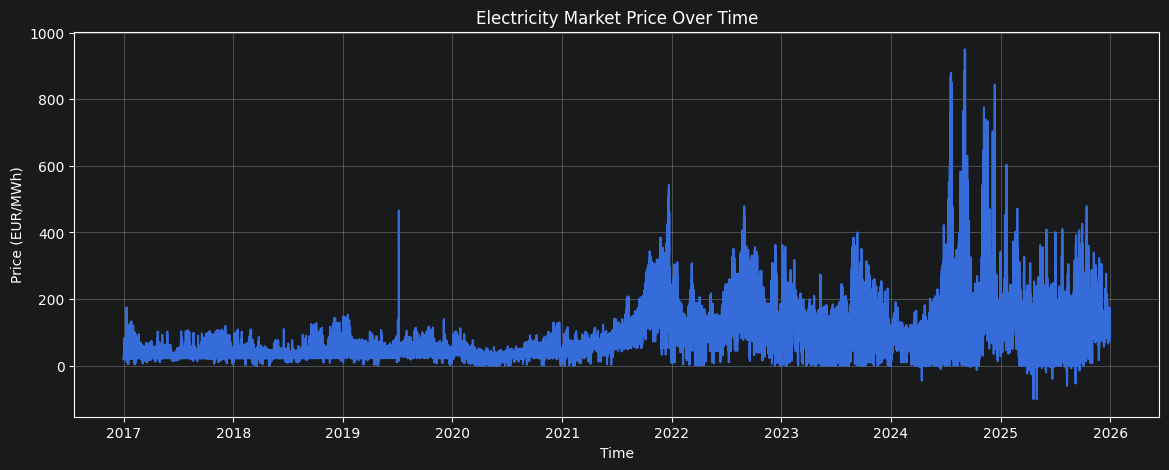

In [9]:
# Step 9. Visualize the price data
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["price"])
plt.title("Electricity Market Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.grid(True)
plt.show()

## Step 10. Create time-based features

In this step, basic calendar features are extracted from the timestamp:
- hour of day
- day of week
- month
- weekend indicator

These variables help the model learn repeating daily, weekly, and seasonal patterns in electricity prices.


In [10]:
# Step 10. Create time-based features
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

## Step 11. Add more calendar features

In this step, additional calendar-based predictors are added:
- day of month
- day of year
- week of year
- quarter
- morning peak indicator
- evening peak indicator

These features provide more detailed time context and can help the model capture recurring market behavior around specific periods and daily demand peaks.


In [12]:
# Step 11. Add more calendar features
df["day_of_month"] = df.index.day
df["day_of_year"] = df.index.dayofyear
df["week_of_year"] = df.index.isocalendar().week.astype(int)
df["quarter"] = df.index.quarter
df["is_morning_peak"] = df["hour"].isin([7, 8, 9]).astype(int)
df["is_evening_peak"] = df["hour"].isin([18, 19, 20, 21]).astype(int)

## Step 12. Create cyclical features

In this step, cyclical encoding is applied to the hour, day of week, and month variables using sine and cosine transformations.

This is useful because time variables are cyclical:
- hour 23 is close to hour 0
- Sunday is close to Monday in a repeating weekly cycle
- December is close to January in a yearly cycle

Cyclical features help the model understand these relationships better than raw integer values alone.


In [13]:
# Step 12. Create cyclical features
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

## Step 13. Create lagging features

In this step, lag features are created from past values of price and load.

Lag features provide the model with information about recent history, which is especially important in time series forecasting. Examples include:
- the previous hour
- the previous day
- the previous week

These predictors often carry strong forecasting power because electricity prices and load are highly dependent on recent past values.


In [14]:
# Step 13. Create lagging features
df["price_lag_1"] = df["price"].shift(1)
df["price_lag_2"] = df["price"].shift(2)
df["price_lag_3"] = df["price"].shift(3)
df["price_lag_24"] = df["price"].shift(24)
df["price_lag_48"] = df["price"].shift(48)
df["price_lag_168"] = df["price"].shift(168)

df["load_lag_1"] = df["load"].shift(1)
df["load_lag_24"] = df["load"].shift(24)
df["load_lag_48"] = df["load"].shift(48)
df["load_lag_168"] = df["load"].shift(168)

## Step 14. Create rolling features

In this step, rolling statistics are added based on previous observations.

Rolling features summarize recent behavior over short windows, such as:
- rolling means
- rolling standard deviation
- rolling maximum
- rolling minimum

These features help the model capture short-term trends and local volatility in price and load.


In [15]:
# Step 14. Create rolling features
df["price_roll_mean_6"] = df["price"].shift(1).rolling(window=6).mean()
df["price_roll_mean_12"] = df["price"].shift(1).rolling(window=12).mean()
df["price_roll_mean_24"] = df["price"].shift(1).rolling(window=24).mean()
df["price_roll_std_24"] = df["price"].shift(1).rolling(window=24).std()
df["price_roll_max_24"] = df["price"].shift(1).rolling(window=24).max()
df["price_roll_min_24"] = df["price"].shift(1).rolling(window=24).min()

df["load_roll_mean_6"] = df["load"].shift(1).rolling(window=6).mean()
df["load_roll_mean_24"] = df["load"].shift(1).rolling(window=24).mean()
df["load_roll_std_24"] = df["load"].shift(1).rolling(window=24).std()

## Step 15. Add correlation analysis

In this step, a correlation matrix is calculated and visualized for selected variables.

This provides a quick overview of the linear relationships between:
- the target-related variables
- the load values
- the time-based features
- the lagged and rolling predictors

This step is useful for understanding which features may carry useful predictive information.



Correlation matrix:
                       price      load          hour   day_of_week  \
price               1.000000  0.270415  1.743154e-01 -1.350400e-01   
load                0.270415  1.000000  3.335705e-01 -1.174642e-01   
hour                0.174315  0.333571  1.000000e+00 -5.121242e-18   
day_of_week        -0.135040 -0.117464 -5.121242e-18  1.000000e+00   
month               0.148324 -0.177275  2.956531e-16  2.450473e-03   
price_lag_1         0.938705  0.248793  1.916921e-01 -1.334772e-01   
price_lag_24        0.852826  0.245133  1.742772e-01  2.653145e-02   
price_lag_168       0.805003  0.247616  1.741625e-01 -1.351060e-01   
load_lag_1          0.263461  0.972296  4.082500e-01 -1.151308e-01   
load_lag_24         0.248707  0.957005  3.336732e-01 -1.702608e-03   
price_roll_mean_24  0.789335  0.152001  1.327626e-04 -6.199763e-02   
load_roll_mean_24   0.155768  0.803319  1.295982e-04 -7.895966e-02   

                           month  price_lag_1  price_lag_24  price_l

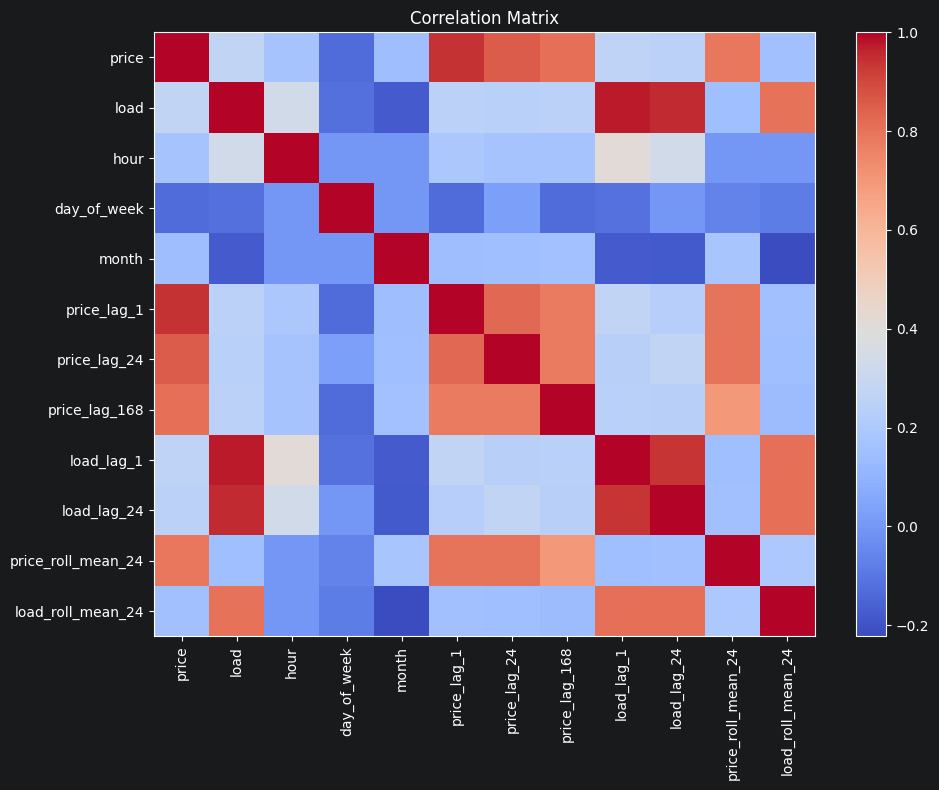

In [16]:
# Step 15. Add correlation analysis
correlation_columns = [
    "price",
    "load",
    "hour",
    "day_of_week",
    "month",
    "price_lag_1",
    "price_lag_24",
    "price_lag_168",
    "load_lag_1",
    "load_lag_24",
    "price_roll_mean_24",
    "load_roll_mean_24"
]

print("\nCorrelation matrix:")
print(df[correlation_columns].corr())

plt.figure(figsize=(10, 8))
plt.imshow(df[correlation_columns].corr(), cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=90)
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Step 16. Create the target value

In this step, the prediction target is created.

The target is defined as the electricity price in the **next hour**, obtained by shifting the current price column one step backward with `shift(-1)`.

This transforms the problem into a supervised learning task where the features at time `t` are used to predict the price at time `t+1`.


In [17]:
# Step 16. Create the target value
df["target_price_next_hour"] = df["price"].shift(-1)

## Step 17. Remove empty rows after the feature engineering

In this step, rows containing missing values are removed.

Missing values appear naturally after creating lagged, rolling, and shifted target features. Dropping these rows ensures that the final training data contains only complete examples.


In [18]:
# Step 17. Remove empty rows after the feature engineering
df = df.dropna()
print("Final dataset shape:", df.shape)
print(df.head())

Final dataset shape: (78719, 38)
                         price    load  hour  day_of_week  month  is_weekend  \
timestamp                                                                      
2017-01-08 00:00:00  63.686517  5373.0     0            6      1           1   
2017-01-08 01:00:00  35.821109  5301.0     1            6      1           1   
2017-01-08 02:00:00  22.547972  5279.0     2            6      1           1   
2017-01-08 03:00:00  22.547972  5295.0     3            6      1           1   
2017-01-08 04:00:00  48.470470  5377.0     4            6      1           1   

                     day_of_month  day_of_year  week_of_year  quarter  ...  \
timestamp                                                              ...   
2017-01-08 00:00:00             8            8             1        1  ...   
2017-01-08 01:00:00             8            8             1        1  ...   
2017-01-08 02:00:00             8            8             1        1  ...   
2017-01-08 03:00

## Step 18. Define the features and the target

In this step, the full feature matrix `X` and the target vector `y` are defined.

The feature list includes:
- load information
- calendar variables
- cyclical encodings
- lagged values
- rolling statistics

The target variable is the next-hour electricity price.


In [19]:
# Step 18. Define the features and the target
feature_columns = [
    "load",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "day_of_month",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_morning_peak",
    "is_evening_peak",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "price_lag_1",
    "price_lag_2",
    "price_lag_3",
    "price_lag_24",
    "price_lag_48",
    "price_lag_168",
    "load_lag_1",
    "load_lag_24",
    "load_lag_48",
    "load_lag_168",
    "price_roll_mean_6",
    "price_roll_mean_12",
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_max_24",
    "price_roll_min_24",
    "load_roll_mean_6",
    "load_roll_mean_24",
    "load_roll_std_24"
]

X = df[feature_columns]
y = df["target_price_next_hour"]

## Step 19. Split the data chronologically

In this step, the dataset is split into training, validation, and test subsets using chronological order.

The split is:
- 70% training
- 15% validation
- 15% test

A chronological split is used instead of a random split because time series forecasting must preserve temporal order. This avoids information leakage from the future into the past.


In [20]:
# Step 19. Split the data chronologically
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (55103, 36)
Validation shape: (11808, 36)
Test shape: (11808, 36)


## Step 20. Create a baseline model

In this step, a simple baseline forecast is created using the previous hour price (`price_lag_1`).

This baseline is important because it provides a reference point. A machine learning model should perform better than this simple persistence-based approach to justify its use.


In [21]:
# Step 20. Create a baseline model
baseline_val_pred = X_val["price_lag_1"]
baseline_test_pred = X_test["price_lag_1"]

## Step 21. Evaluate the base model

In this step, a reusable evaluation function is created and applied to the baseline predictions.

Three metrics are used:
- **MAE** for average absolute error
- **RMSE** for penalizing larger errors more strongly
- **R²** for measuring how much variance is explained

The baseline results on validation and test data provide a benchmark for later comparison.


In [22]:
# Step 21. Evaluate the base model
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

evaluate_model(y_val, baseline_val_pred, "Baseline Validation Results")
evaluate_model(y_test, baseline_test_pred, "Baseline Test Results")

Baseline Validation Results
MAE  : 26.2905
RMSE : 46.3927
R²   : 0.3517
------------------------------
Baseline Test Results
MAE  : 35.1406
RMSE : 60.2906
R²   : 0.3006
------------------------------


## Step 22. Train a gradient boosting model

In this step, the Gradient Boosting regression model is created and trained on the training dataset.

The selected model parameters control:
- the number of boosting stages
- the learning rate
- the depth of each individual tree

Gradient boosting is a strong choice for structured tabular data because it can model non-linear relationships and interactions between features.


In [23]:
# Step 22. Train a gradient boosting model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

## Step 23. Make validation and test predictions

In this step, the trained model is used to generate predictions for the validation and test sets.

The validation predictions are used to inspect model behavior before final testing, while the test predictions are reserved for final evaluation.


In [24]:
# Step 23. Make validation and test predictions
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

## Step 24. Evaluate the model

In this step, the Gradient Boosting model is evaluated using the same metrics as the baseline.

This allows a direct comparison between the machine learning model and the simple previous-hour baseline.


In [25]:
# Step 24. Evaluate the model
evaluate_model(y_val, val_pred, "Gradient Boosting Validation Results")
evaluate_model(y_test, test_pred, "Gradient Boosting Test Results")

Gradient Boosting Validation Results
MAE  : 18.2121
RMSE : 32.7138
R²   : 0.6777
------------------------------
Gradient Boosting Test Results
MAE  : 23.8023
RMSE : 41.9327
R²   : 0.6617
------------------------------


## Step 25. Add a validation plot

In this step, the actual and predicted values on the validation set are plotted for a limited time window.

This visual comparison helps show how closely the model follows the real price movement before looking at the test results.


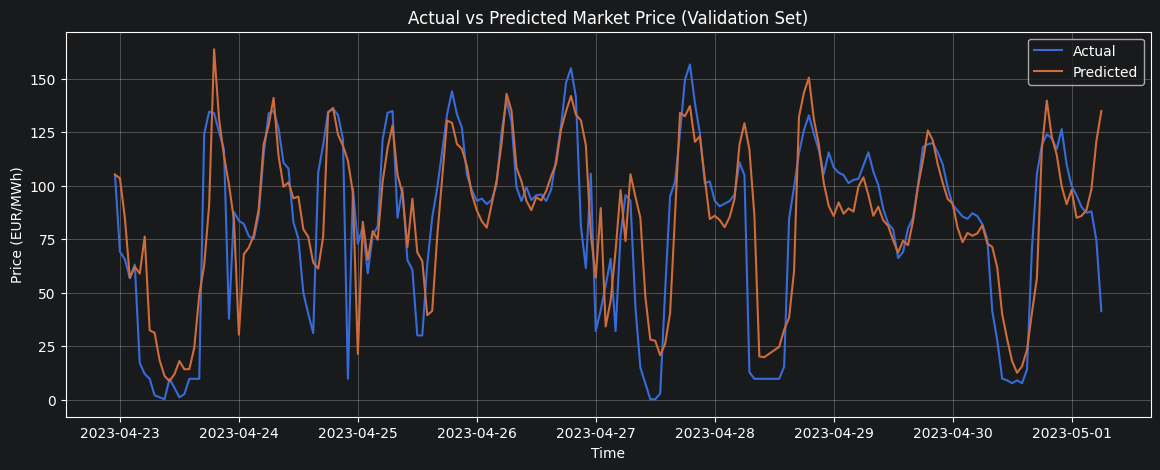

In [26]:
# Step 25. Add a validation plot
plt.figure(figsize=(14, 5))
plt.plot(y_val.index[:200], y_val.iloc[:200], label="Actual")
plt.plot(y_val.index[:200], val_pred[:200], label="Predicted")
plt.title("Actual vs Predicted Market Price (Validation Set)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)
plt.show()

## Step 26. Visualize the actual vs predicted values for the test set

In this step, the actual and predicted electricity prices on the test set are plotted.

This makes it easier to visually inspect model performance on unseen data and observe whether the model captures short-term fluctuations and general trends.


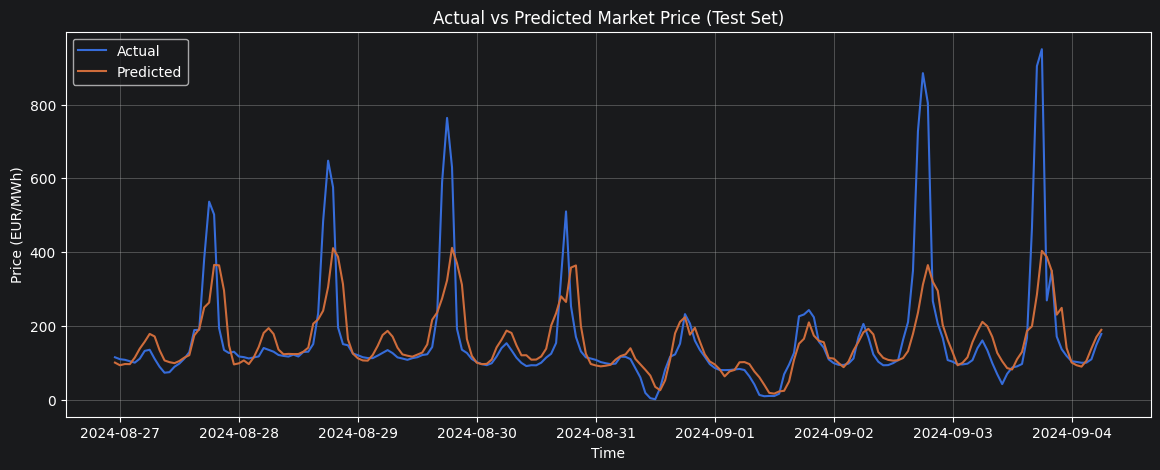

In [27]:
# Step 26. Visualize the actual vs predicted values for the test set
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], test_pred[:200], label="Predicted")
plt.title("Actual vs Predicted Market Price (Test Set)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)
plt.show()

## Step 27. Compare the baseline and the Gradient Boosting model

In this step, the actual values, baseline forecast, and Gradient Boosting predictions are plotted together.

This comparison makes the improvement of the machine learning model easier to interpret visually.


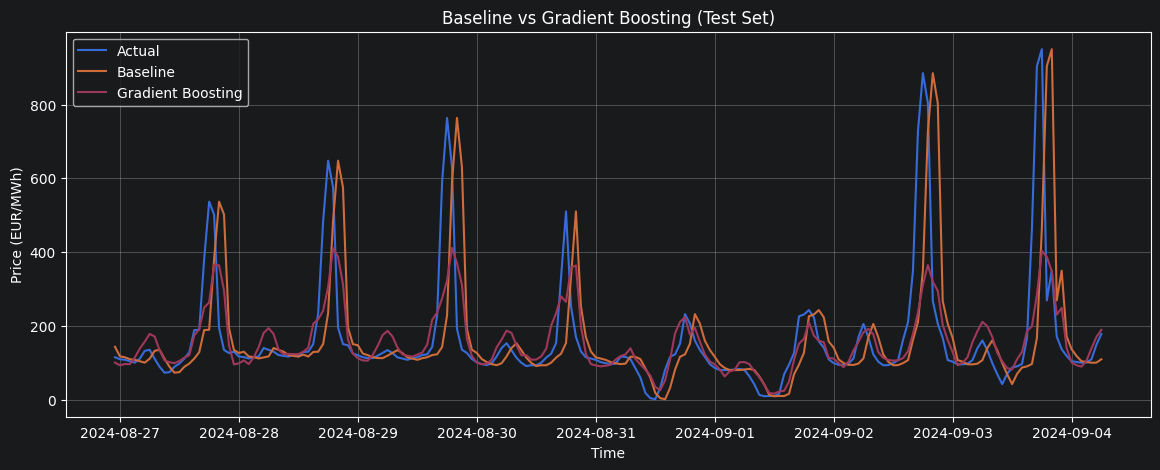

In [28]:
# Step 27. Compare the baseline and the Gradient Boosting model
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], baseline_test_pred.iloc[:200], label="Baseline")
plt.plot(y_test.index[:200], test_pred[:200], label="Gradient Boosting")
plt.title("Baseline vs Gradient Boosting (Test Set)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)
plt.show()

## Step 28. Add error analysis

In this step, a separate results table is created for the test set containing:
- actual values
- predicted values
- prediction error
- absolute error

This makes it easier to inspect the quality of the forecast and summarize the model’s mistakes.


In [29]:
# Step 28. Add error analysis
test_results = pd.DataFrame({
    "actual": y_test,
    "predicted": test_pred
}, index=y_test.index)

test_results["error"] = test_results["actual"] - test_results["predicted"]
test_results["absolute_error"] = np.abs(test_results["error"])

print("\nTest results preview:")
print(test_results.head())

print("\nAbsolute error statistics:")
print(test_results["absolute_error"].describe())


Test results preview:
                     actual   predicted      error  absolute_error
timestamp                                                         
2024-08-26 23:00:00  114.83  100.407166  14.422834       14.422834
2024-08-27 00:00:00  109.65   93.226702  16.423298       16.423298
2024-08-27 01:00:00  107.99   96.536162  11.453838       11.453838
2024-08-27 02:00:00  104.25   96.254360   7.995640        7.995640
2024-08-27 03:00:00  100.27  114.062878 -13.792878       13.792878

Absolute error statistics:
count    11808.000000
mean        23.802329
std         34.523936
min          0.005060
25%          6.439926
50%         13.756968
75%         28.752035
max        654.713603
Name: absolute_error, dtype: float64


## Step 29. Plot the prediction errors

In this step, the prediction errors are visualized in two ways:
- as a time series
- as a histogram

The time-series error plot shows when large mistakes occur, while the histogram shows how the errors are distributed overall.


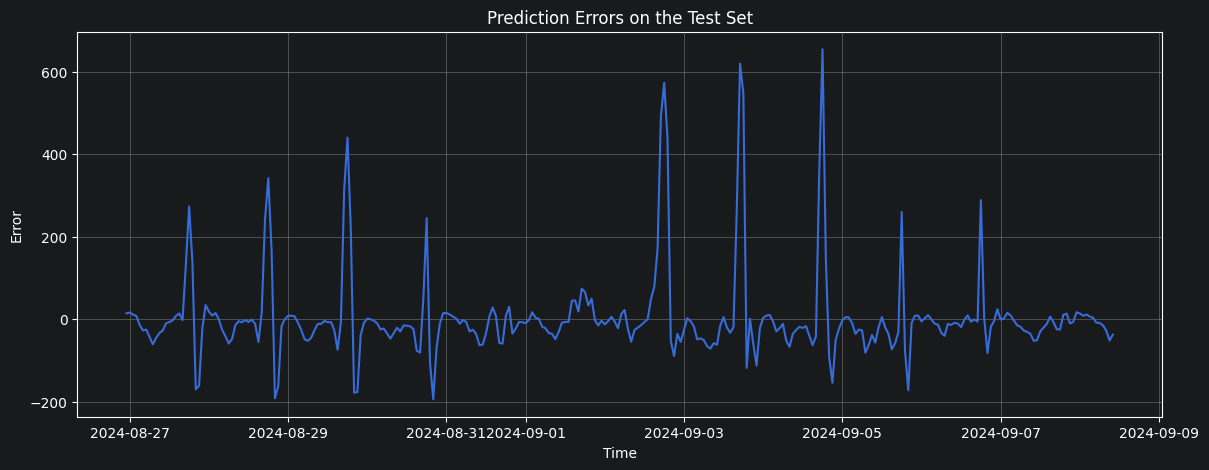

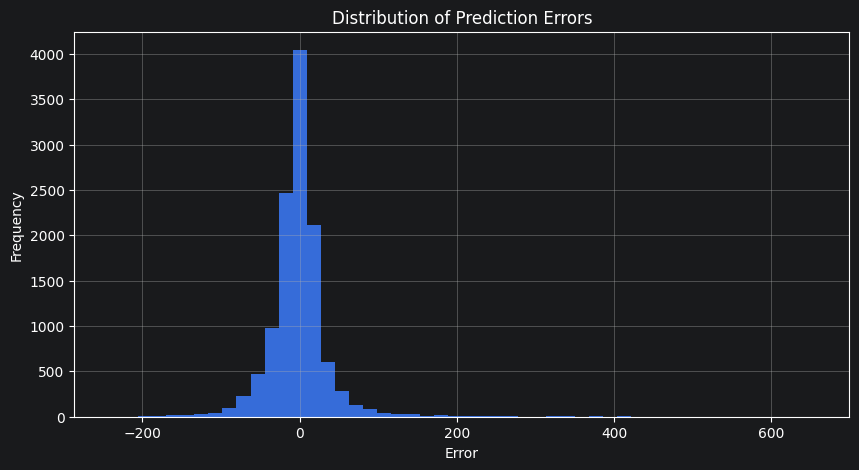

In [30]:
# Step 29. Plot the prediction errors
plt.figure(figsize=(14, 5))
plt.plot(test_results.index[:300], test_results["error"].iloc[:300])
plt.title("Prediction Errors on the Test Set")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(test_results["error"], bins=50)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Step 30. Add performance by hour of day

In this step, the average absolute error is calculated separately for each hour of the day.

This helps identify whether the model performs better during some parts of the day and worse during others, such as peak demand periods.



Average absolute error by hour:
hour
0     11.071231
1      9.894241
2      9.319858
3      7.189495
4     12.399604
5     17.334580
6     28.169000
7     38.093404
8     37.634668
9     30.903370
10    23.822198
11    18.956286
12    16.593385
13    17.660204
14    25.656515
15    39.441332
16    39.086789
17    40.890430
18    44.326365
19    34.885240
20    24.258533
21    19.768560
22    11.856481
23    12.044128
Name: absolute_error, dtype: float64


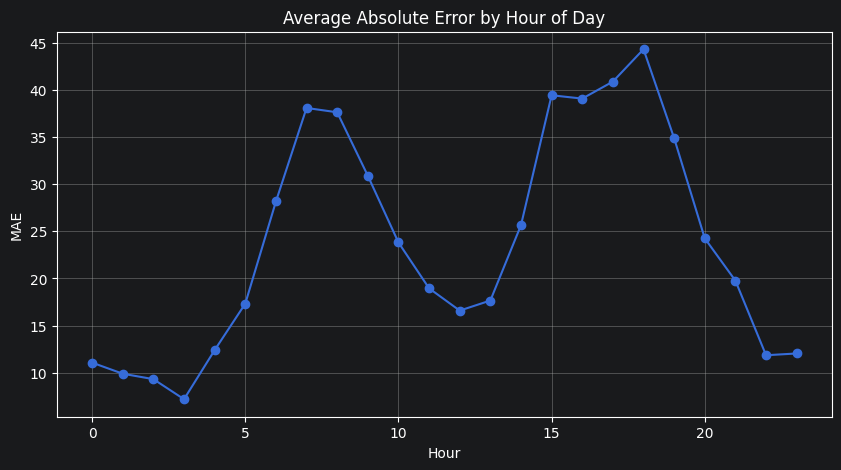

In [31]:
# Step 30. Add performance by hour of day
test_results["hour"] = test_results.index.hour
hourly_mae = test_results.groupby("hour")["absolute_error"].mean()

print("\nAverage absolute error by hour:")
print(hourly_mae)

plt.figure(figsize=(10, 5))
plt.plot(hourly_mae.index, hourly_mae.values, marker="o")
plt.title("Average Absolute Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

## Step 31. Add directional accuracy

In this step, directional accuracy is calculated.

This metric checks whether the model correctly predicts the **direction** of price movement compared to the previous hour:
- increase
- decrease
- no change

Directional accuracy is useful in market forecasting because sometimes predicting the direction correctly is just as important as predicting the exact value.


In [32]:
# Step 31. Add directional accuracy
actual_direction = np.sign(y_test.values - X_test["price_lag_1"].values)
pred_direction = np.sign(test_pred - X_test["price_lag_1"].values)

directional_accuracy = (actual_direction == pred_direction).mean()
print(f"\nDirectional Accuracy: {directional_accuracy:.4f}")


Directional Accuracy: 0.8096


## Step 32. Show the feature importance values

In this step, the feature importance values produced by the Gradient Boosting model are extracted and sorted.

This helps show which input variables contributed most to the forecasting task.


In [33]:
# Step 32. Show the feature importance values
importances = pd.Series(model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

print("\nFeature importances:")
print(importances)


Feature importances:
price_lag_1           0.825266
price_roll_mean_24    0.068980
hour_cos              0.021082
hour_sin              0.018825
price_lag_24          0.016971
price_lag_168         0.009006
hour                  0.007122
price_roll_max_24     0.005641
price_roll_std_24     0.003451
price_lag_48          0.003034
month_cos             0.002869
day_of_week           0.002205
day_of_year           0.001609
price_roll_mean_12    0.001597
load                  0.001321
load_lag_1            0.001216
price_roll_min_24     0.001207
price_lag_3           0.001033
is_weekend            0.000875
load_roll_std_24      0.000808
dow_sin               0.000781
load_roll_mean_24     0.000734
price_roll_mean_6     0.000680
price_lag_2           0.000638
week_of_year          0.000511
dow_cos               0.000449
load_roll_mean_6      0.000444
is_morning_peak       0.000436
day_of_month          0.000231
load_lag_24           0.000214
load_lag_168          0.000184
load_lag_48      

## Step 33. Plot the feature importance

In this final step, the ten most important features are plotted as a horizontal bar chart.

This provides a clear visual summary of which predictors had the strongest effect on the model’s decisions.


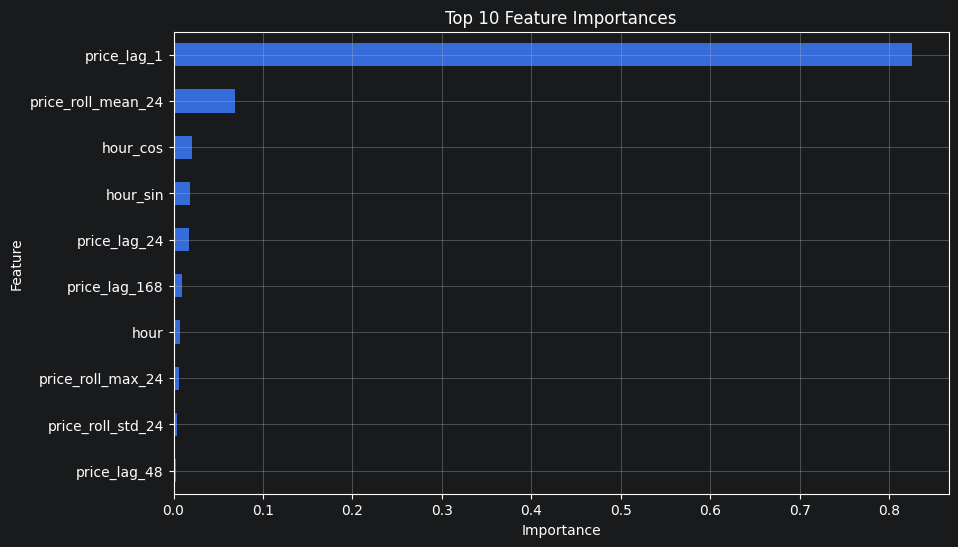

In [34]:
# Step 33. Plot the feature importance
plt.figure(figsize=(10, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()